# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [41]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', None)

In [42]:
df = pd.read_csv('credit_risk_dataset.csv', sep=None, engine='python')

df.shape

(32581, 12)

In [43]:
df.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [45]:
loan_status_dist = df['loan_status'].value_counts()
loan_status_percent = df['loan_status'].value_counts(normalize=True) * 100

loan_status_percent

,proportion
loan_status,
0,78.183604
1,21.816396


Маємо задачу з незбалансованим датасетом (78% vs 22 %). Більшість клієнтів сплатять кредит.


---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [46]:
df.select_dtypes("number").describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [47]:
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_percent

,0
person_age,0.000000
person_income,0.000000
person_home_ownership,0.000000
person_emp_length,2.747000
loan_intent,0.000000
loan_grade,0.000000
loan_amnt,0.000000
loan_int_rate,9.563856
loan_status,0.000000
loan_percent_income,0.000000


In [48]:
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)

/tmp/ipykernel_15747/3887903077.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_15747/3887903077.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' 

In [49]:
Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['person_income'] < lower_bound) | (df['person_income'] > upper_bound)]
df_clean = df[(df['person_income'] >= lower_bound) & (df['person_income'] <= upper_bound)]

In [50]:
total = len(df)
outliers_count = len(outliers)

percentage = outliers_count / total * 100
print(f"{percentage:.2f}%")

4.55%


In [51]:
from enum import unique
cat_cols = df_clean.select_dtypes(include = ['object', 'category']).columns
df_clean[cat_cols].nunique()


,0
person_home_ownership,4
loan_intent,6
loan_grade,7
cb_person_default_on_file,2


In [52]:
fig = px.box(
    df_clean,
    x='loan_status',
    y='loan_amnt',
    title='Cума кредиту vs Дефолт',
    labels={'person_income': 'Сума кретиду', 'loan_status': 'Дефолт'},
    color='loan_status',
    color_discrete_map={'No':'#2ecc71', 'Yes':'#e74c3c'}
)
fig.show()

Позичальники з більшою сумою кредиту - частіше його не виплачують.

In [53]:
fig = px.box(
    df_clean,
    x='loan_status',
    y='loan_percent_income',
    title='Відношення кредиту до доходу vs Дефолт',
    labels={'loan_percent_income': 'Відношення кредиту до доходу', 'loan_status': 'Дефолт'},
    color='loan_status',
    color_discrete_map={'No':'#2ecc71', 'Yes':'#e74c3c'}
)
fig.show()

Позичальники , які мають пропорційно вище відношення кредиту до доходу частіше на сплачують кредит.

In [54]:
loan_status_grade = df.groupby(['loan_grade', 'loan_status']).size().unstack()
loan_status_grade = loan_status_grade.div(loan_status_grade.sum(axis=1), axis=0) * 100

fig = px.bar(
    loan_status_grade,
    title='Дефолт за Кредитним рейтингом',
    labels={'value': 'Відсоток(%)', 'index': 'Дефолт'},
    color_discrete_map={'No':'#2ecc71', 'Yes':'#e74c3c'},
    barmode='group'
)
fig.show()

Чи гірший кредитний рейтинг, тим більша ймовірність, що позичальник не сплатить кредит.


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



In [55]:
metrics_df = df_clean[['person_age','person_income','person_emp_length', 'loan_amnt','loan_int_rate', 'loan_status','loan_percent_income','cb_person_cred_hist_length']].dropna()

correlation_matrix = metrics_df.corr()

fig = px.imshow(
    correlation_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Кореляція між метриками взаємодії',
    labels=dict(color="Кореляція")
)
fig.update_layout(height=500)
fig.show()

In [56]:
all_cat_cols = df_clean.select_dtypes('object').columns.tolist()

In [57]:
selected_cat_cols = ['person_home_ownership', 'loan_intent','loan_grade', 'cb_person_default_on_file']

df_encoded = pd.get_dummies(df, columns=selected_cat_cols, drop_first=True)

In [58]:
df_encoded.head(5)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True


In [59]:
exclude_cols = ['loan_status','person_income','person_emp_length','person_age'] + all_cat_cols
feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]

X = df_encoded[feature_cols]
y = df_encoded['loan_status']

print(f"Кількість ознак: {X.shape[1]}")
print(f"Розмір вибірки: {X.shape[0]}")

Кількість ознак: 19
Розмір вибірки: 32581


In [60]:
X.head()

,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,35000,16.02,0.59,3,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True
1,1000,11.14,0.10,2,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False
2,5500,12.87,0.57,3,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
3,35000,15.23,0.53,2,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False
4,35000,14.27,0.55,4,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True



---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} позичальників")
print(f"Test: {X_test.shape[0]} позичальників")
print(f"Дефолт в train: {y_train.mean():.1%}")
print(f"Дефолт в test: {y_test.mean():.1%}")

Train: 26064 позичальників
Test: 6517 позичальників
Дефолт в train: 21.8%
Дефолт в test: 21.8%


In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
z = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-z))

fig = px.line(
    x=z, y=sigmoid,
    title='Сигмоїда: перетворення чисел на ймовірності',
    labels={'x': 'z (лінійна комбінація ознак)', 'y': 'Ймовірність'}
)
fig.add_hline(y=0.5, line_dash="dash", line_color="red", annotation_text="Поріг рішення")
fig.update_layout(height=400)
fig.show()

In [64]:
from sklearn.linear_model import LogisticRegression

# Створюємо та навчаємо модель
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Модель навчена!")

Модель навчена!


In [65]:
model

LogisticRegression(max_iter=1000, random_state=42)

In [66]:
y_pred = model.predict(X_test_scaled)

y_pred_proba = model.predict_proba(X_test_scaled)

In [67]:
y_pred_proba

array([[0.88507043, 0.11492957],
       [0.9174524 , 0.0825476 ],
       [0.99199751, 0.00800249],
       ...,
       [0.94681037, 0.05318963],
       [0.87946005, 0.12053995],
       [0.94651593, 0.05348407]])

In [68]:
(y_pred_proba[:, 1]>0.6).astype(int)

array([0, 0, 0, ..., 0, 0, 0])

In [69]:
sample_predictions = pd.DataFrame({
    'Реальний дефолт': y_test.values[:5],
    'Прогноз': y_pred[:5],
    'Ймовірність сплатити кредит': y_pred_proba[:5, 0].round(3),
    'Ймовірність дефолту': y_pred_proba[:5, 1].round(3)
})
print(sample_predictions)

   Реальний дефолт  Прогноз  Ймовірність сплатити кредит  Ймовірність дефолту
0                0        0                        0.885                0.115
1                0        0                        0.917                0.083
2                0        0                        0.992                0.008
3                0        0                        0.931                0.069
4                0        0                        0.994                0.006



---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


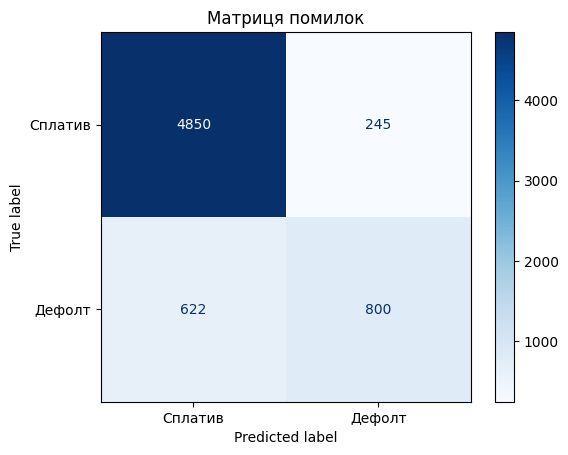

In [70]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Сплатив', 'Дефолт'])
disp.plot(cmap='Blues')
plt.title('Матриця помилок')
plt.show()

In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("МЕТРИКИ ЯКОСТІ МОДЕЛІ:")
print(f"Accuracy (Точність):    {accuracy:.3f}")
print(f"Precision (Влучність):  {precision:.3f}")
print(f"Recall (Повнота):       {recall:.3f}")
print(f"F1-score:               {f1:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ:
Accuracy (Точність):    0.867
Precision (Влучність):  0.766
Recall (Повнота):       0.563
F1-score:               0.649


*  Позичальників у тесті 6517.
*  Правильно виявлений дефолт 802.
*  Пропущений дефолт 620.
*  Помилкові тривоги 244.



In [72]:
from sklearn.metrics import roc_curve, roc_auc_score


fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
auc = roc_auc_score(y_test, y_pred_proba[:, 1])


fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC (AUC = {auc:.3f})'))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'),
                        name='Випадковий класифікатор'))
fig.update_layout(
    title='ROC-крива',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    height=500
)
fig.show()

AUC = 0.87— маємо хорошу модель.

In [73]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0],
    'abs_coefficient': np.abs(model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

feature_importance

,feature,coefficient,abs_coefficient
2,loan_percent_income,1.382583,1.382583
14,loan_grade_D,0.817586,0.817586
0,loan_amnt,-0.615216,0.615216
15,loan_grade_E,0.478554,0.478554
5,person_home_ownership_OWN,-0.443173,0.443173
6,person_home_ownership_RENT,0.438092,0.438092
11,loan_intent_VENTURE,-0.413267,0.413267
7,loan_intent_EDUCATION,-0.319368,0.319368
16,loan_grade_F,0.281439,0.281439
17,loan_grade_G,0.271099,0.271099


На прогноз найбільше впливає відношення кредиту до доходу, кредитний рейтинг Д та Е.


---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



In [92]:
thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
metrics_by_threshold = []

for threshold in thresholds:
    y_pred_custom = (y_pred_proba >= threshold).astype(int)

    metrics_by_threshold.append({
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred_custom),
        'recall': recall_score(y_test, y_pred_custom),
        'f1': f1_score(y_test, y_pred_custom)
    })

metrics_df = pd.DataFrame(metrics_by_threshold)


fig = px.line(
    metrics_df.melt(id_vars='threshold'),
    x='threshold',
    y='value',
    color='variable',
    title='Метрики при різних порогах рішення',
    labels={'value': 'Значення метрики', 'threshold': 'Поріг'},
)
fig.show()

Оптимальний поріг, який оптимізує точність - 0.3.

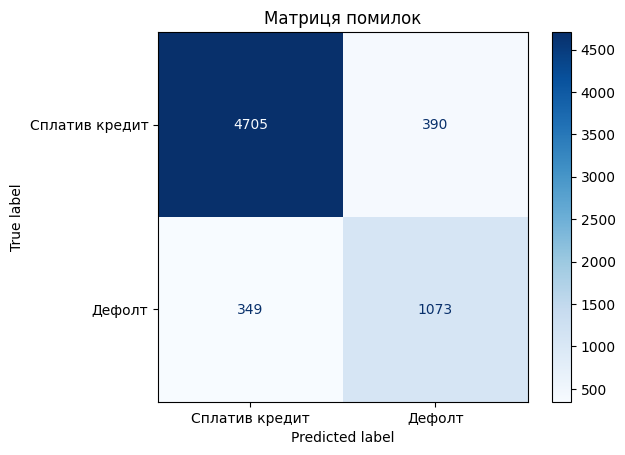

In [95]:
y_pred_opt = y_pred_proba >=0.3
cm = confusion_matrix(y_test, y_pred_opt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Сплатив кредит', 'Дефолт'])
disp.plot(cmap='Blues')
plt.title('Матриця помилок')
plt.show()


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.


In [96]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_pred_proba)
    })

results_df = pd.DataFrame(results).round(3)
print(results_df)

                 Model  Accuracy  Precision  Recall     F1    AUC
0  Logistic Regression     0.867      0.766   0.563  0.649  0.870
1        Decision Tree     0.889      0.838   0.609  0.705  0.860
2        Random Forest     0.911      0.884   0.684  0.771  0.909


*   Правильний вибір порогу може суттємо зменшити втрати.
*   Найбільше прогноз впливає кредитний рейтинг та відношення кредиту до доходу.
*   Чим гірший кредитний рейтинг , тим більша ймовірність дефолту.
*   Позичальники з більшою сукмою кредиту частіше його не виплачують.



